Se carga imagen en rgb y se plotea en el dominio espacial y frecuencial.

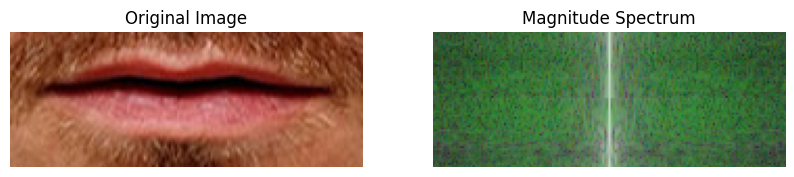

In [7]:
import cv2 as cv
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

imagen_Dir='../images/boca/hb001.jpg'
bgr_img = cv.imread(imagen_Dir) # Carga la imagen en formato BGR
rgb_img = cv.cvtColor(bgr_img, cv.COLOR_BGR2RGB) # Convierte la imagen a formato RGB
rgb_img = np.array(rgb_img, dtype=np.float32)
M, N, _ = rgb_img.shape

fft_img = np.fft.fft2(rgb_img)
fft_shifted = np.fft.fftshift(fft_img)
magnitude_spectrum = 20 * np.log(np.abs(fft_shifted) + 1)  # Adding 1 to avoid log(0)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(rgb_img.astype(np.uint8))
axs[0].set_title('Original Image')
axs[0].axis('off')
axs[1].imshow(magnitude_spectrum.astype(np.uint8), cmap='gray')
axs[1].set_title('Magnitude Spectrum')
axs[1].axis('off')
plt.show()

Se separan los 3 canales de la imagen bgr y se plotean en el dominio frecuencial. Se obtiene la escala de grises en el dominio frecuencial y se plotea en los dos dominios para comprobar que funciona la operación.

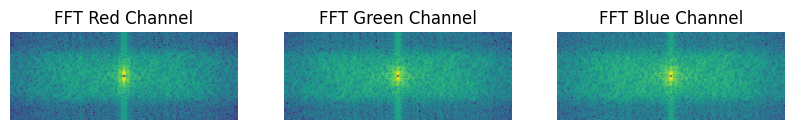

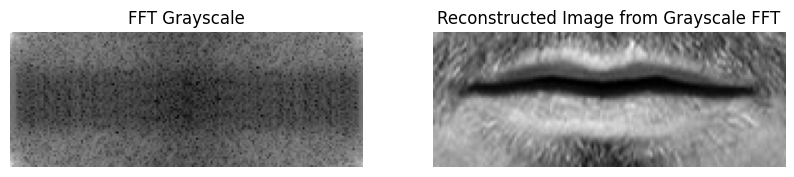

In [30]:
if rgb_img.ndim == 3:
    channels = cv.split(rgb_img)
    freq_channels = [np.fft.fftshift(np.fft.fft2(ch)) for ch in channels]
    F_R, F_G, F_B = freq_channels

F_gray = 0.299 * F_R + 0.587 * F_G + 0.114 * F_B

gray_back = np.abs(np.fft.ifft2(np.fft.ifftshift(F_gray))).astype(np.uint8)
ms_gray_back = 20 * np.log(np.abs(np.fft.ifftshift(F_gray)) + 1)  # Adding 1 to avoid log(0)

ms_R = 20 * np.log(np.abs(F_R) + 1)
ms_G = 20 * np.log(np.abs(F_G) + 1)
ms_B = 20 * np.log(np.abs(F_B) + 1)

max_F_gray = np.max(F_gray)
min_F_gray = np.min(F_gray)

fig, axs = plt.subplots(1, 3, figsize=(10, 5))

axs[0].imshow(ms_R.astype(np.uint8))
axs[0].set_title('FFT Red Channel')
axs[0].axis('off')
axs[1].imshow(ms_G.astype(np.uint8))
axs[1].set_title('FFT Green Channel')
axs[1].axis('off')
axs[2].imshow(ms_B.astype(np.uint8))
axs[2].set_title('FFT Blue Channel')
axs[2].axis('off')
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(ms_gray_back, cmap='gray')
axs[0].set_title('FFT Grayscale')
axs[0].axis('off')
axs[1].imshow(gray_back, cmap='gray')
axs[1].set_title('Reconstructed Image from Grayscale FFT')
axs[1].axis('off')
plt.show()

Ya que tenemos la imagen en escala de grises en el dominio espacial, obtenemos su inversa y ploteamos para confirmar que la operación se aplica.

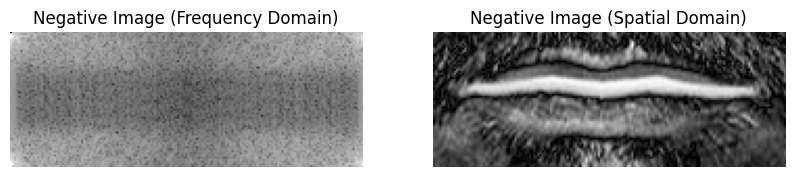

In [66]:
# Obtener negativo en el dominio frecuencial

F_neg = -F_gray
F_neg[M//2, N//2] += (255.0 * M * N)

img_neg_spatial = np.abs(np.fft.ifft2(np.fft.ifftshift(F_neg))).astype(np.uint8)
ms_neg_spatial = 20 * np.log(np.abs(np.fft.ifftshift(F_neg)) + 1)  # Adding 1 to avoid log(0)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(ms_neg_spatial, cmap='gray')
axs[0].set_title('Negative Image (Frequency Domain)')
axs[0].axis('off')
axs[1].imshow(img_neg_spatial, cmap='gray')
axs[1].set_title('Negative Image (Spatial Domain)')
axs[1].axis('off')
plt.show()

Aplicamos un filtro gaussiano al negativo

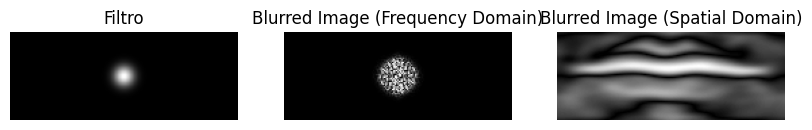

In [64]:
# 1. Creación del filtro Gaussiano (Malla espacial de frecuencias)
u = np.arange(0, M)
v = np.arange(0, N)
U, V = np.meshgrid(v, u)
D2 = (U - N // 2) ** 2 + (V - M // 2) ** 2

# Equivalencia de D0 respecto a OpenCV
# OpenCV con kernel (21,21) calcula un sigma espacial de ~3.5
sigma_espacial = 2.0
# Fórmula de equivalencia aproximada entre dominio espacial y frecuencial:
D0 = min(M, N) / (2 * np.pi * sigma_espacial) 

# Generar la máscara del filtro (El valor máximo será 1.0 en el centro)
H = np.exp(-D2 / (2 * D0**2))

# 3. Aplicar el filtro (Multiplicación elemento a elemento)
F_blur_shift = F_neg * H


# 5. Extraer la parte real y normalizar para visualización
img_blur_freq = np.abs(np.fft.ifft2(np.fft.ifftshift(F_blur_shift))).astype(np.uint8)

fig, axs = plt.subplots(1, 3, figsize=(10, 5))
axs[0].imshow(abs(H), cmap='gray')
axs[0].set_title('Filtro')
axs[0].axis('off')
axs[1].imshow(np.abs(F_blur_shift).astype(np.uint8), cmap='gray')
axs[1].set_title('Blurred Image (Frequency Domain)')
axs[1].axis('off')
axs[2].imshow(img_blur_freq, cmap='gray')
axs[2].set_title('Blurred Image (Spatial Domain)')
axs[2].axis('off')
plt.show()

Dominio Espacial (División no lineal)

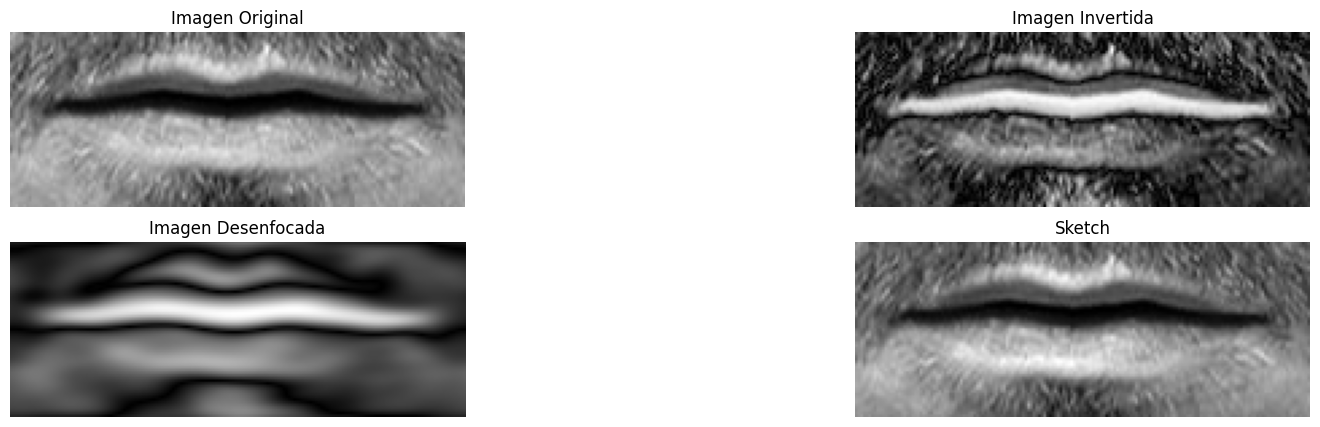

In [65]:

# inverted_image = img_neg_spatial
imagen_blur = np.abs(np.fft.ifft2(np.fft.ifftshift(F_blur_shift))).astype(np.float32)
img_org = gray_back
img = gray_back.astype(np.float32)
epsilon = 1e-6
sketch = cv.divide(img, 255.0 - imagen_blur + epsilon, scale=256.0)
sketch = np.clip(sketch, 0, 255).astype(np.uint8)


fig, axs = plt.subplots(2, 2, figsize=(20, 5))
axs[0, 0].imshow(gray_back, cmap='gray')
axs[0, 0].set_title('Imagen Original')
axs[0, 0].axis('off')
axs[0, 1].imshow(img_neg_spatial, cmap='gray')
axs[0, 1].set_title('Imagen Invertida')
axs[0, 1].axis('off')
axs[1, 0].imshow(imagen_blur, cmap='gray')
axs[1, 0].set_title('Imagen Desenfocada')
axs[1, 0].axis('off')
axs[1, 1].imshow(sketch, cmap='gray')
axs[1, 1].set_title('Sketch')
axs[1, 1].axis('off')
plt.show()

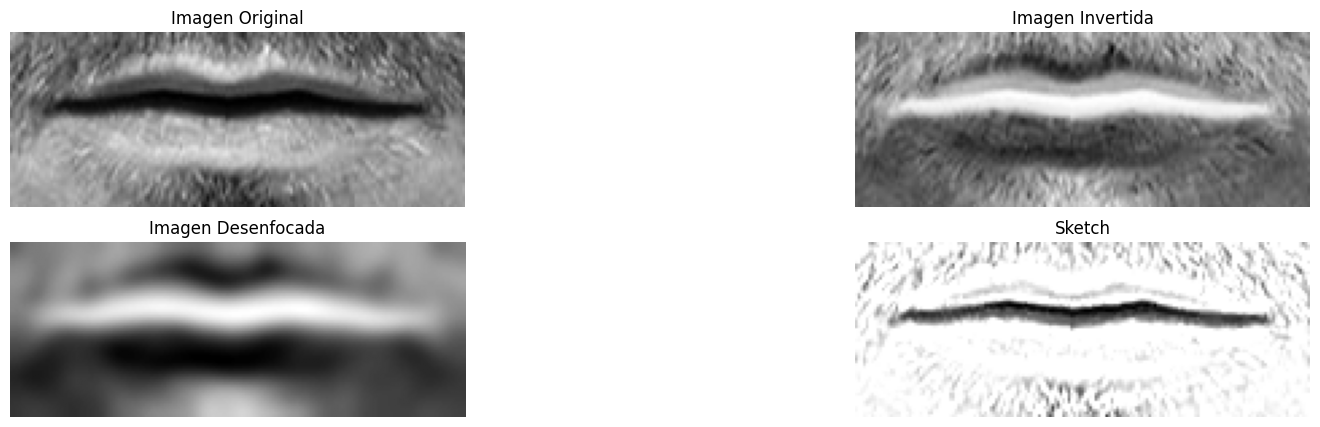

In [55]:
gray_image = cv.cvtColor(bgr_img, cv.COLOR_BGR2GRAY)
inverted_image = cv.bitwise_not(gray_image)
imagen_blur = cv.GaussianBlur(inverted_image, (21, 21), sigmaX=0, sigmaY=0)
img = gray_image.astype(np.float32)
blur = imagen_blur.astype(np.float32)
epsilon = 1e-6
sketch = cv.divide(img, 255.0 - blur + epsilon, scale=256.0)
sketch = np.clip(sketch, 0, 255).astype(np.uint8)

fig, axs = plt.subplots(2, 2, figsize=(20, 5))
axs[0, 0].imshow(gray_image, cmap='gray')
axs[0, 0].set_title('Imagen Original')
axs[0, 0].axis('off')
axs[0, 1].imshow(inverted_image, cmap='gray')
axs[0, 1].set_title('Imagen Invertida')
axs[0, 1].axis('off')
axs[1, 0].imshow(imagen_blur, cmap='gray')
axs[1, 0].set_title('Imagen Desenfocada')
axs[1, 0].axis('off')
axs[1, 1].imshow(sketch, cmap='gray')
axs[1, 1].set_title('Sketch')
axs[1, 1].axis('off')
plt.show()
